Conversion factor: 0.340056 G/MHz
=== Magnetic Field Fits ===
Peak 1: slope = -0.94982 ± 0.01123 G/V, intercept = 0.54277 ± 0.01804 G
Peak 2: slope = 0.00636 ± 0.01016 G/V, intercept = 0.13409 ± 0.01631 G
Peak 3: slope = 0.95490 ± 0.00847 G/V, intercept = -0.22928 ± 0.01359 G
=== Fit Results ===
Peak 1: slope = -0.9498 MHz/V, intercept = 0.5428 MHz
Peak 2: slope = 0.0064 MHz/V, intercept = 0.1341 MHz
Peak 3: slope = 0.9549 MHz/V, intercept = -0.2293 MHz

=== Pairwise Intersections ===
Peak1 & Peak2: x = 0.4274 MHz, y = 0.1368 V
Peak1 & Peak3: x = 0.4053 MHz, y = 0.1578 V
Peak2 & Peak3: x = 0.3831 MHz, y = 0.1365 V


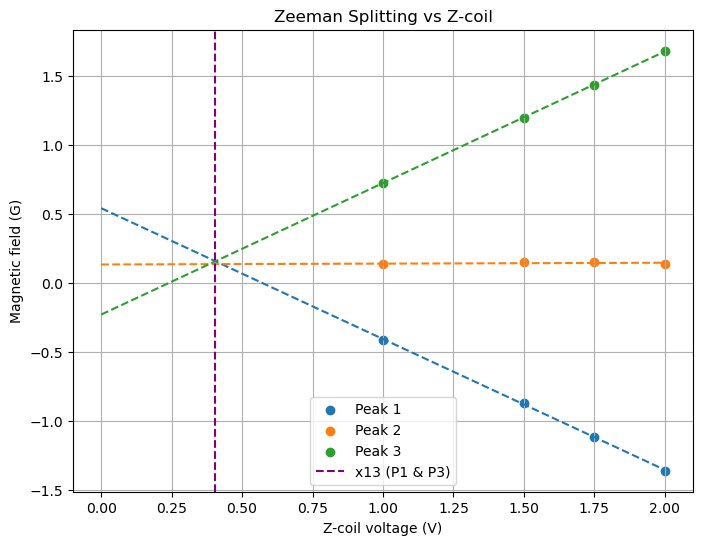

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

gJ = 2.10106
muB_over_h = 1.3996246  # MHz/G

MHz_to_G = 1/(gJ * muB_over_h)

print(f"Conversion factor: {MHz_to_G:.6f} G/MHz")

z_coils = np.array([1, 1.5, 1.75, 2])

peak1 = np.array([-1.211240, -2.569027, -3.284113, -4.008266])
peak2 = np.array([0.401001, 0.439821, 0.440397, 0.413053])
peak3 = np.array([2.141921, 3.530062, 4.223141, 4.958366])


def linear(x, m, b):
    return m * x + b


p1_params, p1_cov = curve_fit(linear, z_coils, peak1)
p2_params, p2_cov = curve_fit(linear, z_coils, peak2) # , bounds=[[0,0.4640], [0.00001,1]]
p3_params, p3_cov = curve_fit(linear, z_coils, peak3)

# Parameter errors (standard deviations)
p1_err = np.sqrt(np.diag(p1_cov))
p2_err = np.sqrt(np.diag(p2_cov))
p3_err = np.sqrt(np.diag(p3_cov))

print("=== Fit Results ===")
print(f"Peak 1: slope = {p1_params[0]:.4f} ± {p1_err[0]:.4f} MHz/V, "
      f"intercept = {p1_params[1]:.4f} ± {p1_err[1]:.4f} MHz")

print(f"Peak 2: slope = {p2_params[0]:.4f} ± {p2_err[0]:.4f} MHz/V, "
      f"intercept = {p2_params[1]:.4f} ± {p2_err[1]:.4f} MHz")

print(f"Peak 3: slope = {p3_params[0]:.4f} ± {p3_err[0]:.4f} MHz/V, "
      f"intercept = {p3_params[1]:.4f} ± {p3_err[1]:.4f} MHz")


print("=== Fit Results ===")
print(f"Peak 1: slope = {p1_params[0]:.4f} MHz/V, intercept = {p1_params[1]:.4f} MHz")
print(f"Peak 2: slope = {p2_params[0]:.4f} MHz/V, intercept = {p2_params[1]:.4f} MHz")
print(f"Peak 3: slope = {p3_params[0]:.4f} MHz/V, intercept = {p3_params[1]:.4f} MHz")


z_fit = np.linspace(0, max(z_coils), 200)


# function to find intersection of two lines
def intersect(m1, b1, m2, b2):
    if np.isclose(m1, m2):
        return None, None  # parallel
    x = (b2 - b1) / (m1 - m2)
    y = m1 * x + b1
    return x, y


# extract parameters
m1, b1 = p1_params
m2, b2 = p2_params
m3, b3 = p3_params

# compute intersections
x12, y12 = intersect(m1, b1, m2, b2)
x13, y13 = intersect(m1, b1, m3, b3)
x23, y23 = intersect(m2, b2, m3, b3)

print("\n=== Pairwise Intersections ===")
print(f"Peak1 & Peak2: x = {x12:.4f} MHz, y = {y12:.4f} V")
print(f"Peak1 & Peak3: x = {x13:.4f} MHz, y = {y13:.4f} V")
print(f"Peak2 & Peak3: x = {x23:.4f} MHz, y = {y23:.4f} V")



plt.figure(figsize=(8,6))


plt.scatter(z_coils, peak1, label='Peak 1', marker='o')
plt.scatter(z_coils, peak2, label='Peak 2', marker='s')
plt.scatter(z_coils, peak3, label='Peak 3', marker='^')


plt.plot(z_fit, linear(z_fit, *p1_params), linestyle='--')
plt.plot(z_fit, linear(z_fit, *p2_params), linestyle='--')
plt.plot(z_fit, linear(z_fit, *p3_params), linestyle='--')

plt.axvline(x=x13, color='purple', linestyle='--', label='x13 (P1 & P3)')

plt.xlabel('Z-coil value')
plt.ylabel('Peak center detuning (MHz)')
plt.title('Peak Positions vs Z-coil')
plt.legend()
plt.grid()

plt.show()



Expected Zeeman slope:
dν/dB = 2.10106 MHz/G

Magnetic field calibration:
Z = 1.00 V   B = 0.79797 G
Z = 1.50 V   B = 1.45143 G
Z = 1.75 V   B = 1.78654 G
Z = 2.00 V   B = 2.13383 G

Fit results (MHz vs G)
Peak 1: slope = -2.09553 ± 0.00721 MHz/G
        intercept = 0.46407 ± 0.01168 MHz
Peak 2: slope = 0.00000 ± 0.06297 MHz/G
        intercept = 0.46400 ± 0.10196 MHz
Peak 3: slope = 2.10660 ± 0.00721 MHz/G
        intercept = 0.46407 ± 0.01168 MHz


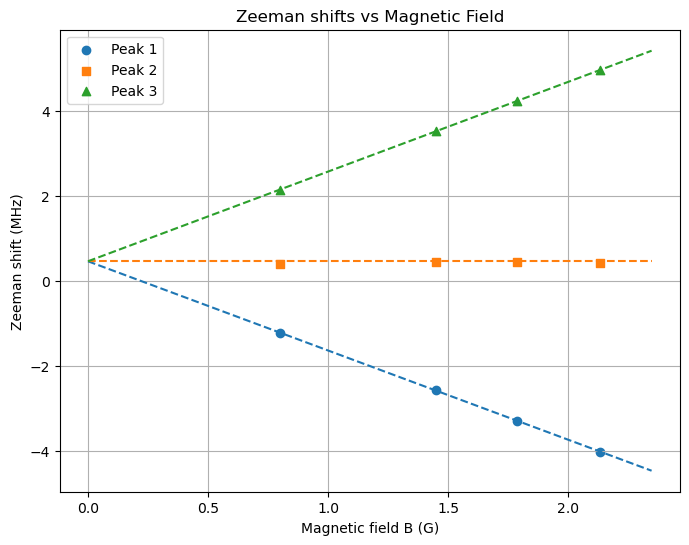

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# ==========================
# Experimental data
# ==========================

z_coils = np.array([1, 1.5, 1.75, 2])  # coil voltage (V)

peak1 = np.array([-1.211240, -2.569027, -3.284113, -4.008266]) # MHz
peak2 = np.array([0.401001, 0.439821, 0.440397, 0.413053])     # MHz
peak3 = np.array([2.141921, 3.530062, 4.223141, 4.958366])     # MHz


# ==========================
# Zeeman parameters
# ==========================

gJ = 1.50116
muB_over_h = 1.3996246   # MHz/G

zeeman_slope = gJ * muB_over_h

print("Expected Zeeman slope:")
print(f"dν/dB = {zeeman_slope:.5f} MHz/G")


# ==========================
# Convert coil voltage to B field
# using splitting between peak1 and peak3
# ==========================

splitting = peak3 - peak1   # MHz

# For mJ=+1 and mJ=-1:
# Δν = 2*gJ*muB/h*B

B_field = splitting / (2 * zeeman_slope)

print("\nMagnetic field calibration:")
for z, B in zip(z_coils, B_field):
    print(f"Z = {z:.2f} V   B = {B:.5f} G")


# ==========================
# Linear fit
# ==========================

def linear(B, slope, intercept):
    return slope * B + intercept


p1, cov1 = curve_fit(linear, B_field, peak1)
p2, cov2 = curve_fit(linear, B_field, peak2, bounds=[[0,0.4640], [0.00001,1]])
p3, cov3 = curve_fit(linear, B_field, peak3)


# errors

err1 = np.sqrt(np.diag(cov1))
err2 = np.sqrt(np.diag(cov2))
err3 = np.sqrt(np.diag(cov3))


print("\n==========================")
print("Fit results (MHz vs G)")
print("==========================")

print(f"Peak 1: slope = {p1[0]:.5f} ± {err1[0]:.5f} MHz/G")
print(f"        intercept = {p1[1]:.5f} ± {err1[1]:.5f} MHz")

print(f"Peak 2: slope = {p2[0]:.5f} ± {err2[0]:.5f} MHz/G")
print(f"        intercept = {p2[1]:.5f} ± {err2[1]:.5f} MHz")

print(f"Peak 3: slope = {p3[0]:.5f} ± {err3[0]:.5f} MHz/G")
print(f"        intercept = {p3[1]:.5f} ± {err3[1]:.5f} MHz")


# ==========================
# Plot
# ==========================

B_fit = np.linspace(0, max(B_field)*1.1, 200)

plt.figure(figsize=(8,6))

plt.scatter(B_field, peak1, marker='o', label="Peak 1")
plt.scatter(B_field, peak2, marker='s', label="Peak 2")
plt.scatter(B_field, peak3, marker='^', label="Peak 3")


plt.plot(B_fit, linear(B_fit,*p1), '--')
plt.plot(B_fit, linear(B_fit,*p2), '--')
plt.plot(B_fit, linear(B_fit,*p3), '--')


plt.xlabel("Magnetic field B (G)")
plt.ylabel("Zeeman shift (MHz)")
plt.title("Zeeman shifts vs Magnetic Field")

plt.grid()
plt.legend()

plt.show()

X b field

Conversion factor: 0.340056 G/MHz
=== Fit Results ===
Peak 1: slope = -1.8705 ± 0.0162 MHz/V, intercept = 0.4597 ± 0.0126 MHz
Peak 2: slope = 0.0000 ± 0.1201 MHz/V, intercept = 0.5398 ± 0.0934 MHz
Peak 3: slope = 1.5764 ± 0.0186 MHz/V, intercept = 0.7147 ± 0.0144 MHz
=== Fit Results ===
Peak 1: slope = -1.8705 MHz/V, intercept = 0.4597 MHz
Peak 2: slope = 0.0000 MHz/V, intercept = 0.5398 MHz
Peak 3: slope = 1.5764 MHz/V, intercept = 0.7147 MHz

=== Pairwise Intersections ===
Peak1 & Peak2: x = -0.0429 MHz, y = 0.5398 V
Peak1 & Peak3: x = -0.0740 MHz, y = 0.5980 V
Peak2 & Peak3: x = -0.1109 MHz, y = 0.5398 V


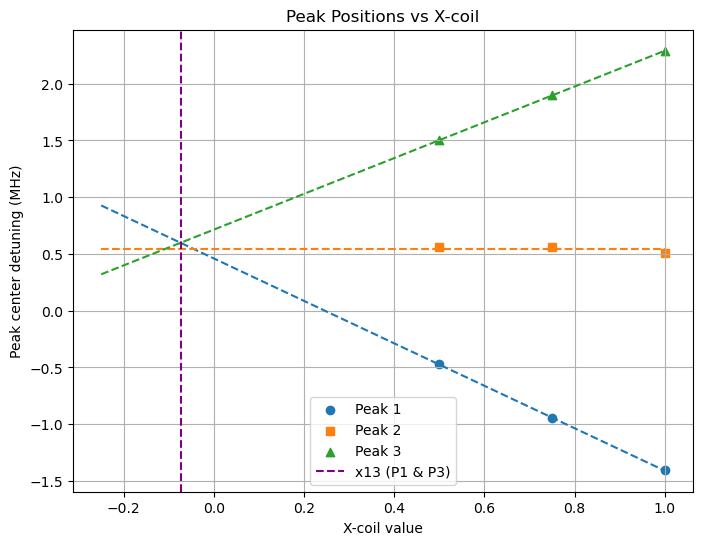

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

gJ = 2.10106
muB_over_h = 1.3996246  # MHz/G

MHz_to_G = 1/(gJ * muB_over_h)

print(f"Conversion factor: {MHz_to_G:.6f} G/MHz")

z_coils = np.array([0.5, 0.75, 1])

peak1 = np.array([-0.473214, -0.947829, -1.408442])
peak2 = np.array([0.557168, 0.557168, 0.505154])
peak3 = np.array([1.500195, 1.902347, 2.288413])


def linear(x, m, b):
    return m * x + b


p1_params, p1_cov = curve_fit(linear, z_coils, peak1)
p2_params, p2_cov = curve_fit(linear, z_coils, peak2, bounds=[[0,0.4640], [0.00001,1]]) # , bounds=[[0,0.4640], [0.00001,1]]
p3_params, p3_cov = curve_fit(linear, z_coils, peak3)

# Parameter errors (standard deviations)
p1_err = np.sqrt(np.diag(p1_cov))
p2_err = np.sqrt(np.diag(p2_cov))
p3_err = np.sqrt(np.diag(p3_cov))

print("=== Fit Results ===")
print(f"Peak 1: slope = {p1_params[0]:.4f} ± {p1_err[0]:.4f} MHz/V, "
      f"intercept = {p1_params[1]:.4f} ± {p1_err[1]:.4f} MHz")

print(f"Peak 2: slope = {p2_params[0]:.4f} ± {p2_err[0]:.4f} MHz/V, "
      f"intercept = {p2_params[1]:.4f} ± {p2_err[1]:.4f} MHz")

print(f"Peak 3: slope = {p3_params[0]:.4f} ± {p3_err[0]:.4f} MHz/V, "
      f"intercept = {p3_params[1]:.4f} ± {p3_err[1]:.4f} MHz")


print("=== Fit Results ===")
print(f"Peak 1: slope = {p1_params[0]:.4f} MHz/V, intercept = {p1_params[1]:.4f} MHz")
print(f"Peak 2: slope = {p2_params[0]:.4f} MHz/V, intercept = {p2_params[1]:.4f} MHz")
print(f"Peak 3: slope = {p3_params[0]:.4f} MHz/V, intercept = {p3_params[1]:.4f} MHz")


z_fit = np.linspace(-0.25, max(z_coils), 200)


# function to find intersection of two lines
def intersect(m1, b1, m2, b2):
    if np.isclose(m1, m2):
        return None, None  # parallel
    x = (b2 - b1) / (m1 - m2)
    y = m1 * x + b1
    return x, y


# extract parameters
m1, b1 = p1_params
m2, b2 = p2_params
m3, b3 = p3_params

# compute intersections
x12, y12 = intersect(m1, b1, m2, b2)
x13, y13 = intersect(m1, b1, m3, b3)
x23, y23 = intersect(m2, b2, m3, b3)

print("\n=== Pairwise Intersections ===")
print(f"Peak1 & Peak2: x = {x12:.4f} MHz, y = {y12:.4f} V")
print(f"Peak1 & Peak3: x = {x13:.4f} MHz, y = {y13:.4f} V")
print(f"Peak2 & Peak3: x = {x23:.4f} MHz, y = {y23:.4f} V")



plt.figure(figsize=(8,6))


plt.scatter(z_coils, peak1, label='Peak 1', marker='o')
plt.scatter(z_coils, peak2, label='Peak 2', marker='s')
plt.scatter(z_coils, peak3, label='Peak 3', marker='^')


plt.plot(z_fit, linear(z_fit, *p1_params), linestyle='--')
plt.plot(z_fit, linear(z_fit, *p2_params), linestyle='--')
plt.plot(z_fit, linear(z_fit, *p3_params), linestyle='--')

plt.axvline(x=x13, color='purple', linestyle='--', label='x13 (P1 & P3)')

plt.xlabel('X-coil value')
plt.ylabel('Peak center detuning (MHz)')
plt.title('Peak Positions vs X-coil')
plt.legend()
plt.grid()

plt.show()



Expected Zeeman slope:
dν/dB = 2.10106 MHz/G

Magnetic field calibration:
Z = 0.50 V   B = 0.46962 G
Z = 0.75 V   B = 0.67827 G
Z = 1.00 V   B = 0.87976 G

Fit results (MHz vs G)
Peak 1: slope = -2.28025 ± 0.00327 MHz/G
        intercept = 0.59802 ± 0.00228 MHz
Peak 2: slope = 0.00000 ± 0.14643 MHz/G
        intercept = 0.53983 ± 0.10196 MHz
Peak 3: slope = 1.92187 ± 0.00327 MHz/G
        intercept = 0.59802 ± 0.00228 MHz


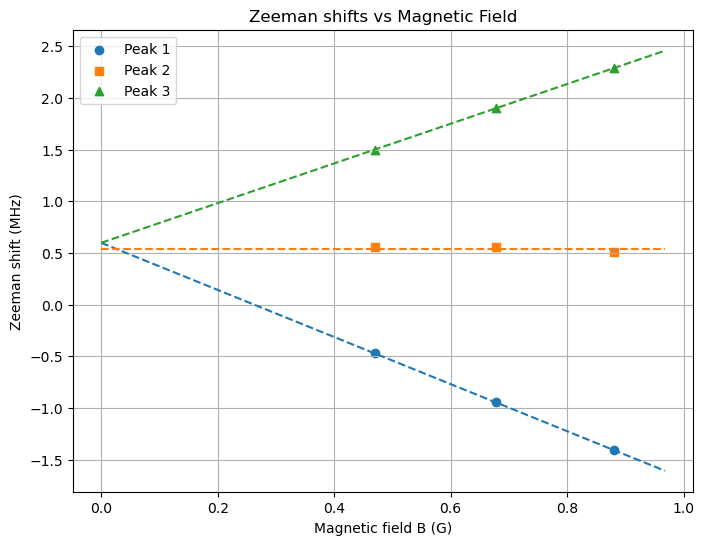

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# ==========================
# Experimental data
# ==========================

z_coils = np.array([0.5, 0.75, 1])

peak1 = np.array([-0.473214, -0.947829, -1.408442])
peak2 = np.array([0.557168, 0.557168, 0.505154])
peak3 = np.array([1.500195, 1.902347, 2.288413])


# ==========================
# Zeeman parameters
# ==========================

gJ = 1.50116
muB_over_h = 1.3996246   # MHz/G

zeeman_slope = gJ * muB_over_h

print("Expected Zeeman slope:")
print(f"dν/dB = {zeeman_slope:.5f} MHz/G")


# ==========================
# Convert coil voltage to B field
# using splitting between peak1 and peak3
# ==========================

splitting = peak3 - peak1   # MHz

# For mJ=+1 and mJ=-1:
# Δν = 2*gJ*muB/h*B

B_field = splitting / (2 * zeeman_slope)

print("\nMagnetic field calibration:")
for z, B in zip(z_coils, B_field):
    print(f"Z = {z:.2f} V   B = {B:.5f} G")


# ==========================
# Linear fit
# ==========================

def linear(B, slope, intercept):
    return slope * B + intercept


p1, cov1 = curve_fit(linear, B_field, peak1)
p2, cov2 = curve_fit(linear, B_field, peak2, bounds=[[0,0.4640], [0.00001,1]])
p3, cov3 = curve_fit(linear, B_field, peak3)


# errors

err1 = np.sqrt(np.diag(cov1))
err2 = np.sqrt(np.diag(cov2))
err3 = np.sqrt(np.diag(cov3))


print("\n==========================")
print("Fit results (MHz vs G)")
print("==========================")ac

print(f"Peak 1: slope = {p1[0]:.5f} ± {err1[0]:.5f} MHz/G")
print(f"        intercept = {p1[1]:.5f} ± {err1[1]:.5f} MHz")

print(f"Peak 2: slope = {p2[0]:.5f} ± {err2[0]:.5f} MHz/G")
print(f"        intercept = {p2[1]:.5f} ± {err2[1]:.5f} MHz")

print(f"Peak 3: slope = {p3[0]:.5f} ± {err3[0]:.5f} MHz/G")
print(f"        intercept = {p3[1]:.5f} ± {err3[1]:.5f} MHz")


# ==========================
# Plot
# ==========================

B_fit = np.linspace(0, max(B_field)*1.1, 200)

plt.figure(figsize=(8,6))

plt.scatter(B_field, peak1, marker='o', label="Peak 1")
plt.scatter(B_field, peak2, marker='s', label="Peak 2")
plt.scatter(B_field, peak3, marker='^', label="Peak 3")


plt.plot(B_fit, linear(B_fit,*p1), '--')
plt.plot(B_fit, linear(B_fit,*p2), '--')
plt.plot(B_fit, linear(B_fit,*p3), '--')


plt.xlabel("Magnetic field B (G)")
plt.ylabel("Zeeman shift (MHz)")
plt.title("Zeeman shifts vs Magnetic Field")

plt.grid()
plt.legend()

plt.show()

Peak 1: a = 0.29507
Peak 3: a = 0.08801
Peak 1: b = -0.39776
Peak 3: b = -0.34527
Peak 1: c = -3.54542
Peak 3: c = 2.73044


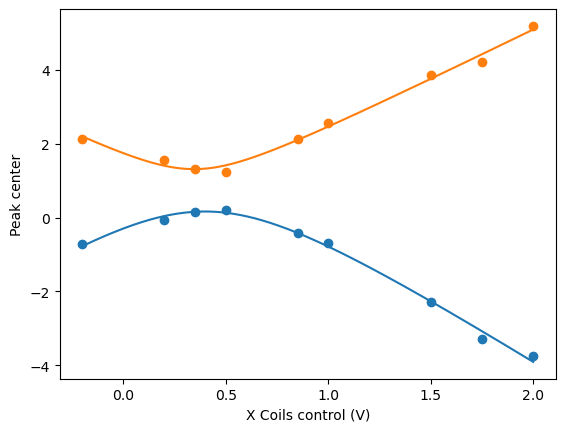

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

z_all = np.array([
 1.0, 1.5, 1.75, 2.0, 0.2, 0.35, 0.5,  0.85, -0.2])


p1_all = np.array([
 -0.681044, -2.290014, -3.284113, -3.757778,  -0.062724, 0.138989,  0.195532,  -0.428235, -0.715891])


p3_all = np.array([
 2.547953, 3.848854, 4.223141, 5.189518, 1.556015, 1.327434, 1.243658, 2.116476, 2.118080])

# Model
def model(z, a, b, c, d):
    return c * np.sqrt(np.maximum(a + (b + z)**2, 0))+d

# Better initial guesses
p0_1 = [1.0, 0.0, -1.0, 0]   # Peak 1 (negative)
p0_3 = [0.4, 0.0, 1.0, 0]    # Peak 3 (positive)

# Bounds: a ≥ 0
bounds = ([-2, -np.inf, -np.inf, -np.inf], [np.inf, np.inf, np.inf, np.inf])

# Fit
params1, _ = curve_fit(model, z_all, p1_all, p0=p0_1, bounds=bounds)
params3, _ = curve_fit(model, z_all, p3_all, p0=p0_3, bounds=bounds)

a1, b1, c1, d1 = params1
a3, b3, c3, d3 = params3

# Print b values
print(f"Peak 1: a = {a1:.5f}")
print(f"Peak 3: a = {a3:.5f}")
print(f"Peak 1: b = {b1:.5f}")
print(f"Peak 3: b = {b3:.5f}")
print(f"Peak 1: c = {c1:.5f}")
print(f"Peak 3: c = {c3:.5f}")
# Smooth curve
x_fit = np.linspace(z_all.min(), z_all.max(), 500)

# Plot
plt.figure()

plt.scatter(z_all, p1_all)
plt.scatter(z_all, p3_all)

plt.plot(x_fit, model(x_fit, *params1))
plt.plot(x_fit, model(x_fit, *params3))

plt.xlabel("X Coils control (V)")
plt.ylabel("Peak center")

plt.show()


*Y COILS*

Conversion factor: 0.340056 G/MHz
=== Fit Results ===
Peak 1: slope = -0.0222 ± 0.0021 MHz/V, intercept = 0.1491 ± 0.0165 MHz
Peak 2: slope = 0.0000 ± 0.0061 MHz/V, intercept = 0.5547 ± 0.0471 MHz
Peak 3: slope = 0.0262 ± 0.0079 MHz/V, intercept = 0.9100 ± 0.0612 MHz
=== Fit Results ===
Peak 1: slope = -0.0222 MHz/V, intercept = 0.1491 MHz
Peak 2: slope = 0.0000 MHz/V, intercept = 0.5547 MHz
Peak 3: slope = 0.0262 MHz/V, intercept = 0.9100 MHz

=== Pairwise Intersections ===
Peak1 & Peak2: x = -18.2372 MHz, y = 0.5547 V
Peak1 & Peak3: x = -15.6968 MHz, y = 0.4982 V
Peak2 & Peak3: x = -13.5434 MHz, y = 0.5547 V


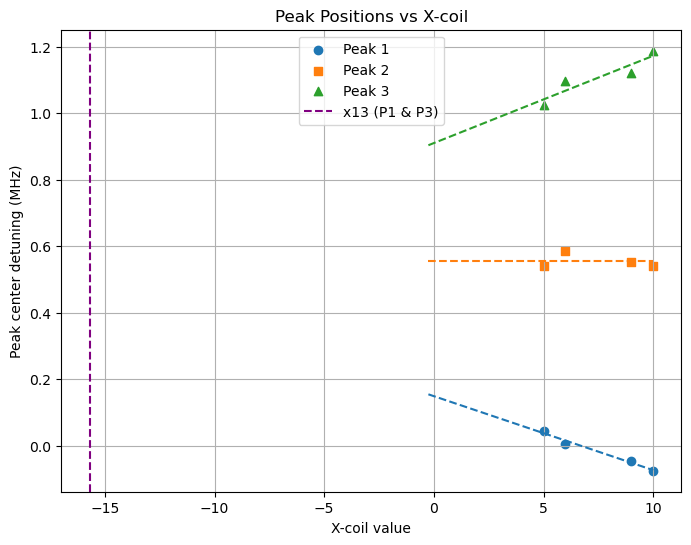

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

gJ = 2.10106
muB_over_h = 1.3996246  # MHz/G

MHz_to_G = 1/(gJ * muB_over_h)

print(f"Conversion factor: {MHz_to_G:.6f} G/MHz")

z_coils = np.array([5, 6, 9, 10])

peak1 = np.array([0.044462, 0.006362, -0.046573, -0.075006])
peak2 = np.array([0.541412, 0.584383, 0.551618, 0.541370])
peak3 = np.array([1.023118, 1.096620, 1.119839, 1.187592])


def linear(x, m, b):
    return m * x + b


p1_params, p1_cov = curve_fit(linear, z_coils, peak1)
p2_params, p2_cov = curve_fit(linear, z_coils, peak2, bounds=[[0,0.4640], [0.00001,1]]) # , bounds=[[0,0.4640], [0.00001,1]]
p3_params, p3_cov = curve_fit(linear, z_coils, peak3)

# Parameter errors (standard deviations)
p1_err = np.sqrt(np.diag(p1_cov))
p2_err = np.sqrt(np.diag(p2_cov))
p3_err = np.sqrt(np.diag(p3_cov))

print("=== Fit Results ===")
print(f"Peak 1: slope = {p1_params[0]:.4f} ± {p1_err[0]:.4f} MHz/V, "
      f"intercept = {p1_params[1]:.4f} ± {p1_err[1]:.4f} MHz")

print(f"Peak 2: slope = {p2_params[0]:.4f} ± {p2_err[0]:.4f} MHz/V, "
      f"intercept = {p2_params[1]:.4f} ± {p2_err[1]:.4f} MHz")

print(f"Peak 3: slope = {p3_params[0]:.4f} ± {p3_err[0]:.4f} MHz/V, "
      f"intercept = {p3_params[1]:.4f} ± {p3_err[1]:.4f} MHz")


print("=== Fit Results ===")
print(f"Peak 1: slope = {p1_params[0]:.4f} MHz/V, intercept = {p1_params[1]:.4f} MHz")
print(f"Peak 2: slope = {p2_params[0]:.4f} MHz/V, intercept = {p2_params[1]:.4f} MHz")
print(f"Peak 3: slope = {p3_params[0]:.4f} MHz/V, intercept = {p3_params[1]:.4f} MHz")


z_fit = np.linspace(-0.25, max(z_coils), 200)


# function to find intersection of two lines
def intersect(m1, b1, m2, b2):
    if np.isclose(m1, m2):
        return None, None  # parallel
    x = (b2 - b1) / (m1 - m2)
    y = m1 * x + b1
    return x, y


# extract parameters
m1, b1 = p1_params
m2, b2 = p2_params
m3, b3 = p3_params

# compute intersections
x12, y12 = intersect(m1, b1, m2, b2)
x13, y13 = intersect(m1, b1, m3, b3)
x23, y23 = intersect(m2, b2, m3, b3)

print("\n=== Pairwise Intersections ===")
print(f"Peak1 & Peak2: x = {x12:.4f} MHz, y = {y12:.4f} V")
print(f"Peak1 & Peak3: x = {x13:.4f} MHz, y = {y13:.4f} V")
print(f"Peak2 & Peak3: x = {x23:.4f} MHz, y = {y23:.4f} V")



plt.figure(figsize=(8,6))


plt.scatter(z_coils, peak1, label='Peak 1', marker='o')
plt.scatter(z_coils, peak2, label='Peak 2', marker='s')
plt.scatter(z_coils, peak3, label='Peak 3', marker='^')


plt.plot(z_fit, linear(z_fit, *p1_params), linestyle='--')
plt.plot(z_fit, linear(z_fit, *p2_params), linestyle='--')
plt.plot(z_fit, linear(z_fit, *p3_params), linestyle='--')

plt.axvline(x=x13, color='purple', linestyle='--', label='x13 (P1 & P3)')

plt.xlabel('X-coil value')
plt.ylabel('Peak center detuning (MHz)')
plt.title('Peak Positions vs X-coil')
plt.legend()
plt.grid()

plt.show()



Peak 1 fit:
f1(Y) = -1.20433 Z + -0.50980 MHz

Peak 2 fit:
f2(Y) = 0.25746 Z + 0.39934 MHz

Peak 3 fit:
f3(Y) = 1.20050 Z + 1.54171 MHz

Peak 1–Peak 3 intersection:
Y-coil setting = -0.85308
Peak frequency = 0.51759 MHz

Values at Z = 0:
Peak 1 = -0.50980 MHz
Peak 2 = 0.39934 MHz
Peak 3 = 1.54171 MHz


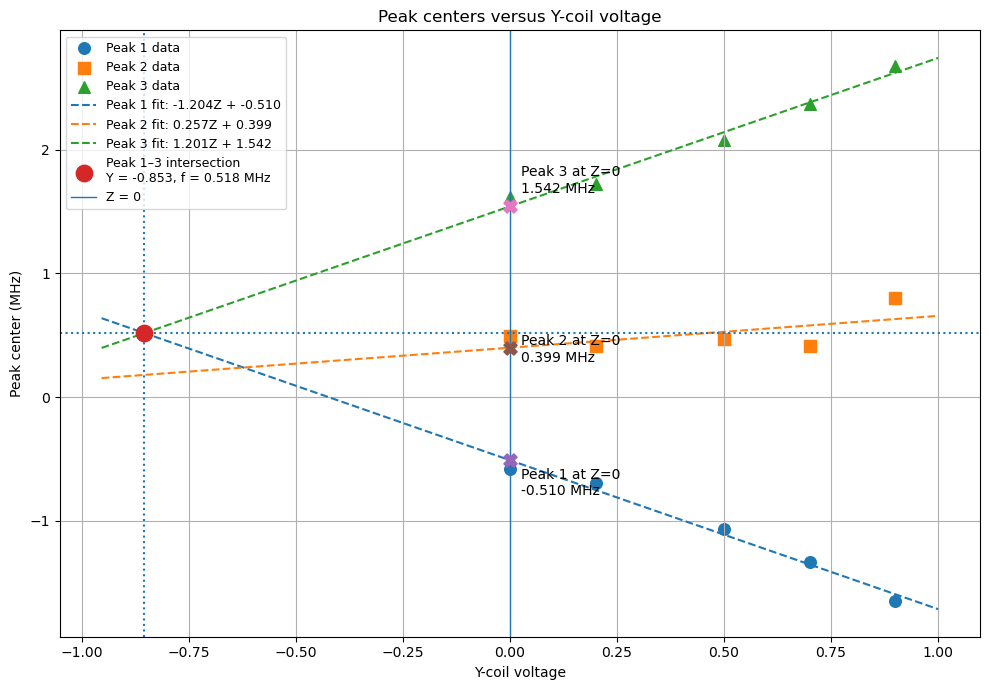

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# ==========================
# Experimental data
# ==========================

z_coils = np.array([0, 0.2, .5,.7, .9])

peak1 = np.array([
    -0.579383,
    -0.695372,
    -1.062368,
    -1.332421,
    -1.649412
])

peak2 = np.array([
    0.493225,
    0.410749,
    0.468615,
    0.416257,
    0.800000
])

peak3 = np.array([
    1.615198,
    1.724106,
    2.082169,
    2.372900,
    2.675323
])


# ==========================
# Linear fit
# ==========================

def linear(x, slope, intercept):
    return slope * x + intercept


p1, cov1 = curve_fit(linear, z_coils, peak1)
p2, cov2 = curve_fit(linear, z_coils, peak2)
p3, cov3 = curve_fit(linear, z_coils, peak3)

m1, b1 = p1
m2, b2 = p2
m3, b3 = p3


# ==========================
# Intersection of Peak 1 and Peak 3
# ==========================

z_intersection = (b3 - b1) / (m1 - m3)
frequency_intersection = linear(z_intersection, m1, b1)

print("Peak 1 fit:")
print(f"f1(Y) = {m1:.5f} Z + {b1:.5f} MHz")

print("\nPeak 2 fit:")
print(f"f2(Y) = {m2:.5f} Z + {b2:.5f} MHz")

print("\nPeak 3 fit:")
print(f"f3(Y) = {m3:.5f} Z + {b3:.5f} MHz")

print("\nPeak 1–Peak 3 intersection:")
print(f"Y-coil setting = {z_intersection:.5f}")
print(f"Peak frequency = {frequency_intersection:.5f} MHz")

print("\nValues at Z = 0:")
print(f"Peak 1 = {b1:.5f} MHz")
print(f"Peak 2 = {b2:.5f} MHz")
print(f"Peak 3 = {b3:.5f} MHz")


# ==========================
# Plot
# ==========================

# Include both zero and the extrapolated intersection
z_min = min(0, z_intersection) - 0.1
z_max = max(z_coils.max(), z_intersection) + 0.1
z_fit = np.linspace(z_min, z_max, 500)

plt.figure(figsize=(10, 7))

# Experimental points
plt.scatter(
    z_coils, peak1,
    marker="o",
    s=70,
    label="Peak 1 data"
)

plt.scatter(
    z_coils, peak2,
    marker="s",
    s=70,
    label="Peak 2 data"
)

plt.scatter(
    z_coils, peak3,
    marker="^",
    s=70,
    label="Peak 3 data"
)

# Fitted lines
plt.plot(
    z_fit,
    linear(z_fit, *p1),
    "--",
    label=f"Peak 1 fit: {m1:.3f}Z + {b1:.3f}"
)

plt.plot(
    z_fit,
    linear(z_fit, *p2),
    "--",
    label=f"Peak 2 fit: {m2:.3f}Z + {b2:.3f}"
)

plt.plot(
    z_fit,
    linear(z_fit, *p3),
    "--",
    label=f"Peak 3 fit: {m3:.3f}Z + {b3:.3f}"
)

# Peak 1–Peak 3 intersection
plt.scatter(
    z_intersection,
    frequency_intersection,
    s=140,
    zorder=10,
    label=(
        "Peak 1–3 intersection\n"
        f"Y = {z_intersection:.3f}, "
        f"f = {frequency_intersection:.3f} MHz"
    )
)

plt.axvline(
    z_intersection,
    linestyle=":",
    linewidth=1.5
)

plt.axhline(
    frequency_intersection,
    linestyle=":",
    linewidth=1.5
)

# Values of fitted lines at Z = 0
plt.scatter(
    0,
    b1,
    s=90,
    marker="X",
    zorder=10
)

plt.scatter(
    0,
    b2,
    s=90,
    marker="X",
    zorder=10
)

plt.scatter(
    0,
    b3,
    s=90,
    marker="X",
    zorder=10
)

plt.annotate(
    f"Peak 1 at Z=0\n{b1:.3f} MHz",
    xy=(0, b1),
    xytext=(8, -25),
    textcoords="offset points"
)

plt.annotate(
    f"Peak 2 at Z=0\n{b2:.3f} MHz",
    xy=(0, b2),
    xytext=(8, -10),
    textcoords="offset points"
)

plt.annotate(
    f"Peak 3 at Z=0\n{b3:.3f} MHz",
    xy=(0, b3),
    xytext=(8, 10),
    textcoords="offset points"
)

plt.axvline(
    0,
    linewidth=1,
    linestyle="-",
    label="Z = 0"
)

plt.xlabel("Y-coil voltage")
plt.ylabel("Peak center (MHz)")
plt.title("Peak centers versus Y-coil voltage")

plt.grid(True)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

Peak 1 fit:
f1(Z) = -0.36639 Z + -0.36371 MHz

Peak 2 fit:
f2(Z) = -0.15219 Z + 0.53176 MHz

Peak 3 fit:
f3(Z) = 0.37014 Z + 1.40451 MHz

Peak 1–Peak 3 intersection:
Z = -2.40075
Frequency = 0.51591 MHz

Values at Z = 0:
Peak 1 = -0.36371 MHz
Peak 2 = 0.53176 MHz
Peak 3 = 1.40451 MHz


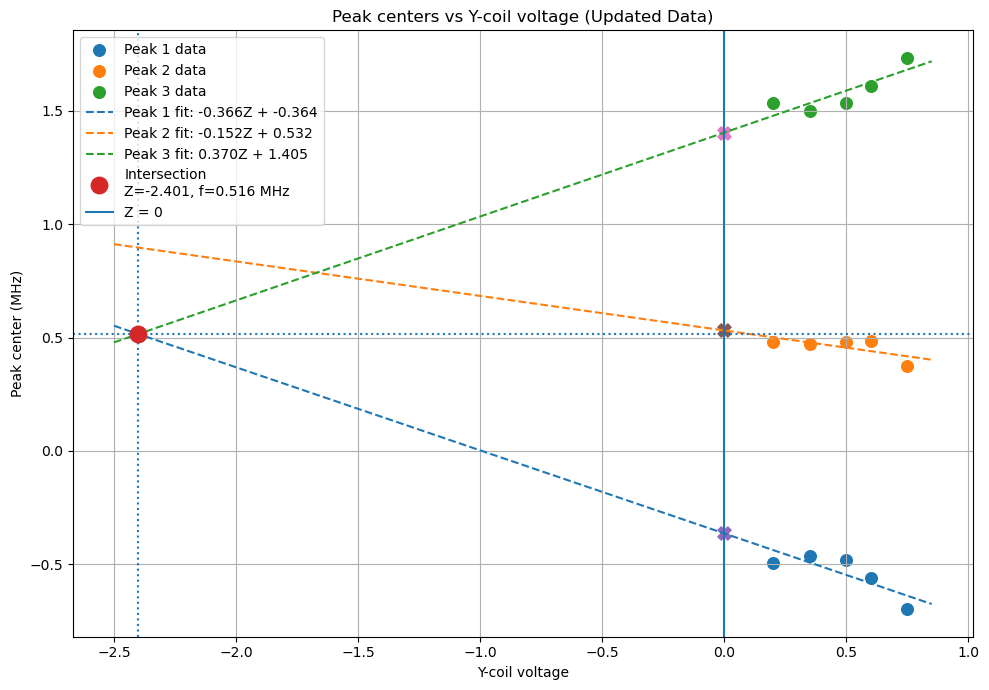

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# ==========================
# Experimental data (UPDATED)
# ==========================
z_coils = np.array([0, 0.2, .5,.7, .9])

peak1 = np.array([
    -0.579383,
    -0.695372,
    -1.062368,
    -1.332421,
    -1.649412
])

peak2 = np.array([
    0.493225,
    0.410749,
    0.468615,
    0.416257,
    0.800000
])

peak3 = np.array([
    1.615198,
    1.724106,
    2.082169,
    2.372900,
    2.675323
])

z_coils = -np.array([0.2, 0.35, 0.5, 0.6, 0.75])

# Triple Gaussian centers
peak1 = np.array([
    -0.494690,
    -0.461197,
    -0.481829,
    -0.562431,
    -0.697742
])

peak2 = np.array([
    0.482582,
    0.473829,
    0.478664,
    0.483300,
    0.375188
])

peak3 = np.array([
    1.534253,
    1.498020,
    1.534547,
    1.610132,
    1.733931
])

# #Skewed Gaussians Peaks
# peak1 = np.array([-0.284415, -0.233123, -0.240701, -0.340886, -0.487163])
# peak2 = np.array([0.625344, 0.628855, 0.625343, 0.678933, 0.506588])
# peak3 = np.array([1.769400, 1.744202, 1.758894, 1.834568, 1.947652])

# ==========================
# Linear fit
# ==========================

def linear(x, slope, intercept):
    return slope * x + intercept


p1, cov1 = curve_fit(linear, z_coils, peak1)
p2, cov2 = curve_fit(linear, z_coils, peak2)
p3, cov3 = curve_fit(linear, z_coils, peak3)

m1, b1 = p1
m2, b2 = p2
m3, b3 = p3


# ==========================
# Intersection of Peak 1 and Peak 3
# ==========================

z_intersection = (b3 - b1) / (m1 - m3)
frequency_intersection = linear(z_intersection, m1, b1)

print("Peak 1 fit:")
print(f"f1(Z) = {m1:.5f} Z + {b1:.5f} MHz")

print("\nPeak 2 fit:")
print(f"f2(Z) = {m2:.5f} Z + {b2:.5f} MHz")

print("\nPeak 3 fit:")
print(f"f3(Z) = {m3:.5f} Z + {b3:.5f} MHz")

print("\nPeak 1–Peak 3 intersection:")
print(f"Z = {z_intersection:.5f}")
print(f"Frequency = {frequency_intersection:.5f} MHz")

print("\nValues at Z = 0:")
print(f"Peak 1 = {b1:.5f} MHz")
print(f"Peak 2 = {b2:.5f} MHz")
print(f"Peak 3 = {b3:.5f} MHz")


# ==========================
# Plot
# ==========================

z_min = min(0, z_intersection) - 0.1
z_max = max(z_coils.max(), z_intersection) + 0.1
z_fit = np.linspace(z_min, z_max, 500)

plt.figure(figsize=(10, 7))

# Experimental points
plt.scatter(z_coils, peak1, s=70, label="Peak 1 data")
plt.scatter(z_coils, peak2, s=70, label="Peak 2 data")
plt.scatter(z_coils, peak3, s=70, label="Peak 3 data")

# Fitted lines
plt.plot(z_fit, linear(z_fit, *p1), "--", label=f"Peak 1 fit: {m1:.3f}Z + {b1:.3f}")
plt.plot(z_fit, linear(z_fit, *p2), "--", label=f"Peak 2 fit: {m2:.3f}Z + {b2:.3f}")
plt.plot(z_fit, linear(z_fit, *p3), "--", label=f"Peak 3 fit: {m3:.3f}Z + {b3:.3f}")

# Intersection
plt.scatter(z_intersection, frequency_intersection, s=140, zorder=10,
            label=f"Intersection\nZ={z_intersection:.3f}, f={frequency_intersection:.3f} MHz")

plt.axvline(z_intersection, linestyle=":")
plt.axhline(frequency_intersection, linestyle=":")

# Z = 0 intercepts
plt.scatter(0, b1, marker="X", s=90)
plt.scatter(0, b2, marker="X", s=90)
plt.scatter(0, b3, marker="X", s=90)

plt.axvline(0, linestyle="-", label="Z = 0")

plt.xlabel("Y-coil voltage")
plt.ylabel("Peak center (MHz)")
plt.title("Peak centers vs Y-coil voltage (Updated Data)")

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Peak 1: b = 0.29381
Peak 3: b = 0.28721


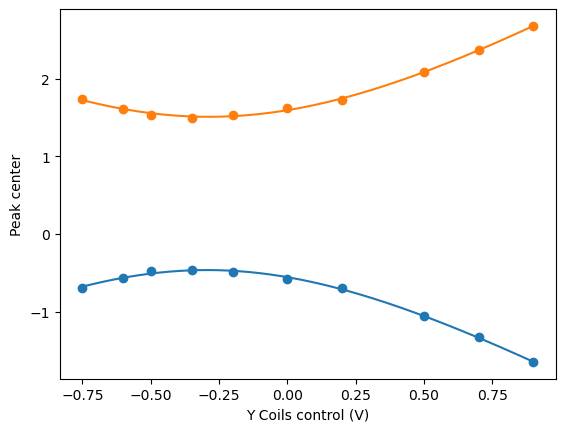

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ==========================
# Dataset 1 (positive Z)
# ==========================
z1 = np.array([0.0, 0.2, 0.5, 0.6, 0.7, 0.9, 1.0])

p1_1 = np.array([
    -0.414,
    -0.5722,
    -0.891,
    -1.052,
    -1.172,
    -1.494,
    -1.643
])

p2_1 = np.array([
    0.750,
    0.6182,
    0.511,
    0.390,
    0.800,
    0.320,
    0.513
])

p3_1 = np.array([
    1.775,
    1.9032,
    2.276,
    2.420,
    2.556,
    2.197,
    3.004
])

# ==========================
# Dataset 2 (negative Z)
# ==========================
z2 = -np.array([0.2, 0.35, 0.5])

p1_2 = np.array([
    -0.341,
    -0.303,
    -0.331
])

p2_2 = np.array([
    0.598,
    0.473,
    0.408
])

p3_2 = np.array([
    1.681,
    1.674,
    1.767
])

# ==========================
# Combine
# ==========================
z_all = np.concatenate([z1, z2])
p1_all = np.concatenate([p1_1, p1_2])
p3_all = np.concatenate([p3_1, p3_2])

# ==========================
# Model
# ==========================
def model(z, a, b, c, d):
    return c * np.sqrt(np.maximum(a + (b + z)**2, 0)) + d

# Initial guesses
p0_1 = [1.0, 0.0, -1.0, 0]   # Peak 1 (negative)
p0_3 = [1.0, 0.0, 1.0, 0]    # Peak 3 (positive)

# Bounds: a ≥ 0
bounds = ([0, -np.inf, -np.inf, -np.inf],
          [np.inf, np.inf, np.inf, np.inf])

# ==========================
# Fit
# ==========================
params1, _ = curve_fit(model, z_all, p1_all, p0=p0_1, bounds=bounds)
params3, _ = curve_fit(model, z_all, p3_all, p0=p0_3, bounds=bounds)

a1, b1, c1, d1 = params1
a3, b3, c3, d3 = params3

# ==========================
# Print results
# ==========================
print(f"Peak 1: b = {b1:.5f}")
print(f"Peak 3: b = {b3:.5f}")

# ==========================
# Smooth curve
# ==========================
z_fit = np.linspace(z_all.min(), z_all.max(), 500)

# ==========================
# Plot
# ==========================
plt.figure()

plt.scatter(z_all, p1_all, label="Peak 1")
plt.scatter(z_all, p3_all, label="Peak 3")

plt.plot(z_fit, model(z_fit, *params1), '--')
plt.plot(z_fit, model(z_fit, *params3), '--')

plt.xlabel("Y Coils control (V)")
plt.ylabel("Peak center")

plt.legend()
plt.grid()

plt.show()

NEW MEASARES

Peak 1: b = 0.35064
Peak 3: b = 0.24742


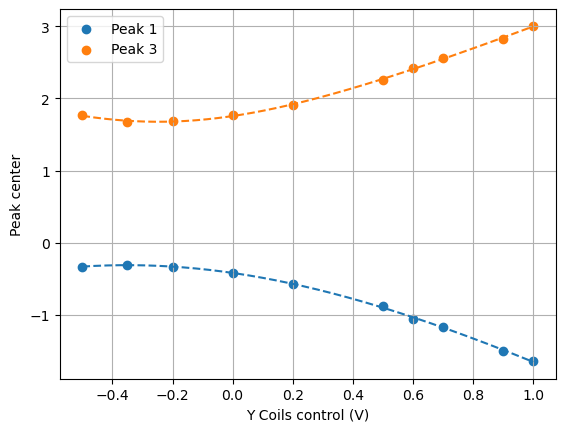

In [101]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ==========================
# Dataset 1 (positive Z)
# ==========================
z1 = np.array([0.0, 0.2, 0.5, 0.6, 0.7, 0.9, 1.0])

p1_1 = np.array([
    -0.414,
    -0.5722,
    -0.877,
    -1.052,
    -1.172,
    -1.494,
    -1.643
])

p2_1 = np.array([
    0.750,
    0.6182,
    0.511,
    0.390,
    0.800,
    0.320,
    0.513
])

p3_1 = np.array([
    1.775,
    1.9032,
    2.258,
    2.420,
    2.556,
    2.827,
    3.004
])

# ==========================
# Dataset 2 (negative Z)
# ==========================
z2 = -np.array([0.2, 0.35, 0.5])

p1_2 = np.array([
    -0.341,
    -0.303,
    -0.331
])

p2_2 = np.array([
    0.598,
    0.473,
    0.408
])

p3_2 = np.array([
    1.681,
    1.674,
    1.767
])

# ==========================
# Combine
# ==========================
z_all = np.concatenate([z1, z2])
p1_all = np.concatenate([p1_1, p1_2])
p3_all = np.concatenate([p3_1, p3_2])

# ==========================
# Model
# ==========================
def model(z, a, b, c, d):
    return c * np.sqrt(np.maximum(a + (b + z)**2, 0)) + d

# Initial guesses
p0_1 = [1.0, 0.0, -1.0, 0]   # Peak 1 (negative)
p0_3 = [1.0, 0.0, 1.0, 0]    # Peak 3 (positive)

# Bounds: a ≥ 0
bounds = ([0, -np.inf, -np.inf, -np.inf],
          [np.inf, np.inf, np.inf, np.inf])

# ==========================
# Fit
# ==========================
params1, _ = curve_fit(model, z_all, p1_all, p0=p0_1, bounds=bounds)
params3, _ = curve_fit(model, z_all, p3_all, p0=p0_3, bounds=bounds)

a1, b1, c1, d1 = params1
a3, b3, c3, d3 = params3

# ==========================
# Print results
# ==========================
print(f"Peak 1: b = {b1:.5f}")
print(f"Peak 3: b = {b3:.5f}")

# ==========================
# Smooth curve
# ==========================
z_fit = np.linspace(z_all.min(), z_all.max(), 500)

# ==========================
# Plot
# ==========================
plt.figure()

plt.scatter(z_all, p1_all, label="Peak 1")
plt.scatter(z_all, p3_all, label="Peak 3")

plt.plot(z_fit, model(z_fit, *params1), '--')
plt.plot(z_fit, model(z_fit, *params3), '--')

plt.xlabel("Y Coils control (V)")
plt.ylabel("Peak center")

plt.legend()
plt.grid()

plt.show()

Expected Zeeman slope:
dν/dB = 2.10106 MHz/G

Fixed zero-field Zeeman fit
Zero field position Y0 = -0.300 V
c = 3.88483 ± 0.41434 MHz/V

Expected:
2*gJ*muB/h = 4.20212 MHz/G

Zero field check:
B(-0.300) = 0.00000 G


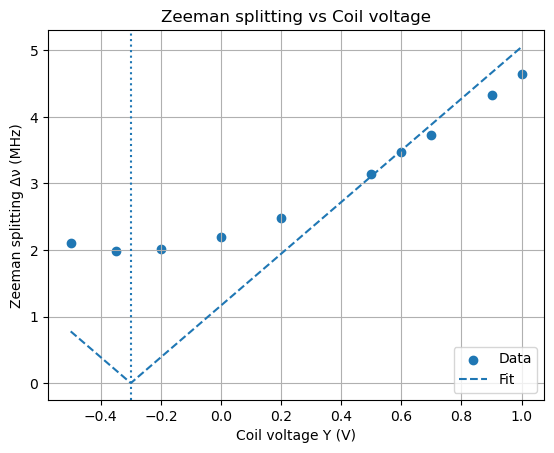

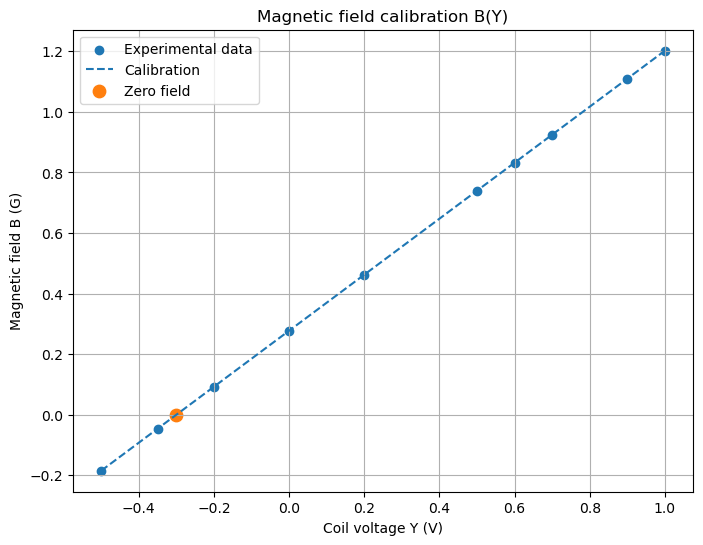

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# ==========================
# Dataset 1 (positive Z)
# ==========================
y1 = np.array([0.0, 0.2, 0.5, 0.6, 0.7, 0.9, 1.0])

p1_1 = np.array([
    -0.414,
    -0.5722,
    -0.877,
    -1.052,
    -1.172,
    -1.494,
    -1.643
])

p2_1 = np.array([
    0.750,
    0.6182,
    0.511,
    0.390,
    0.800,
    0.320,
    0.513
])

p3_1 = np.array([
    1.775,
    1.9032,
    2.258,
    2.420,
    2.556,
    2.827,
    3.004
])


# ==========================
# Dataset 2 (negative Z)
# ==========================
y2 = -np.array([0.2, 0.35, 0.5])

p1_2 = np.array([
    -0.341,
    -0.303,
    -0.331
])

p2_2 = np.array([
    0.598,
    0.473,
    0.408
])

p3_2 = np.array([
    1.681,
    1.674,
    1.767
])


# ==========================
# Combine datasets
# ==========================
y_all = np.concatenate([y1, y2])
p1_all = np.concatenate([p1_1, p1_2])
p2_all = np.concatenate([p2_1, p2_2])
p3_all = np.concatenate([p3_1, p3_2])


# ==========================
# Zeeman parameters
# ==========================
gJ = 1.50116
muB_over_h = 1.3996246

zeeman_slope = gJ * muB_over_h

print("Expected Zeeman slope:")
print(f"dν/dB = {zeeman_slope:.5f} MHz/G")


# ==========================
# Zeeman splitting
# ==========================
splitting = p3_all - p1_all


# ==========================
# Fixed zero field model
# ==========================

Y0 = -0.3


def zeeman_model_fixed(y, c):
    return c * np.abs(y - Y0)


p0 = [2 * zeeman_slope]


params, cov = curve_fit(
    zeeman_model_fixed,
    y_all,
    splitting,
    p0=p0
)

err = np.sqrt(np.diag(cov))

c_fit = params[0]


print("\n==========================")
print("Fixed zero-field Zeeman fit")
print("==========================")

print(f"Zero field position Y0 = {Y0:.3f} V")
print(f"c = {c_fit:.5f} ± {err[0]:.5f} MHz/V")

print("\nExpected:")
print(f"2*gJ*muB/h = {2*zeeman_slope:.5f} MHz/G")


# ==========================
# Conversion Y -> B
# ==========================

alpha = c_fit / (2*zeeman_slope)


def Y_to_B(y):
    return alpha*(y - Y0)


B_gauss = Y_to_B(y_all)


print("\n==========================")
print("Magnetic field calibration")
print("==========================")

print(f"B(Y) = {alpha:.5f}*(Y + 0.300) G")


for y, B in sorted(zip(y_all, B_gauss)):
    print(f"Y = {y: .3f} V   B = {B:.5f} G")


print("\nZero field check:")
print(f"B(-0.300) = {Y_to_B(-0.3):.5f} G")


# ==========================
# Plot Δν(Y)
# ==========================

Y_plot = np.linspace(min(y_all), max(y_all), 300)

plt.figure()

plt.scatter(y_all, splitting, label="Data")
plt.plot(
    Y_plot,
    zeeman_model_fixed(Y_plot, c_fit),
    '--',
    label="Fit"
)

plt.axvline(Y0, linestyle=":")
plt.xlabel("Coil voltage Y (V)")
plt.ylabel("Zeeman splitting Δν (MHz)")
plt.title("Zeeman splitting vs Coil voltage")
plt.grid()
plt.legend()



# ==========================
# Plot Y -> B
# ==========================

B_plot = Y_to_B(Y_plot)

plt.figure(figsize=(8,6))

plt.scatter(
    y_all,
    B_gauss,
    label="Experimental data"
)

plt.plot(
    Y_plot,
    B_plot,
    '--',
    label="Calibration"
)

plt.scatter(
    Y0,
    0,
    s=80,
    label="Zero field"
)

plt.xlabel("Coil voltage Y (V)")
plt.ylabel("Magnetic field B (G)")
plt.title("Magnetic field calibration B(Y)")
plt.grid()
plt.legend()

plt.show()

# old values

Expected Zeeman slope:
dν/dB = 2.10106 MHz/G

Zeeman splitting fit
a = 0.79441 ± 0.22847
b = 0.29012 ± 0.01624
c = 3.92192 ± 0.27735
d = -1.50268 ± 0.73869

Fit results ν(B)
Peak 1: slope = -1.97335 ± 0.02398
Peak 2: slope = -0.13255 ± 0.20971
Peak 3: slope = 1.94857 ± 0.02608


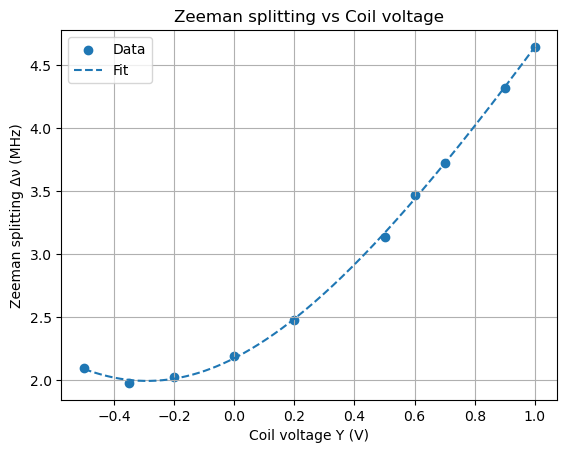

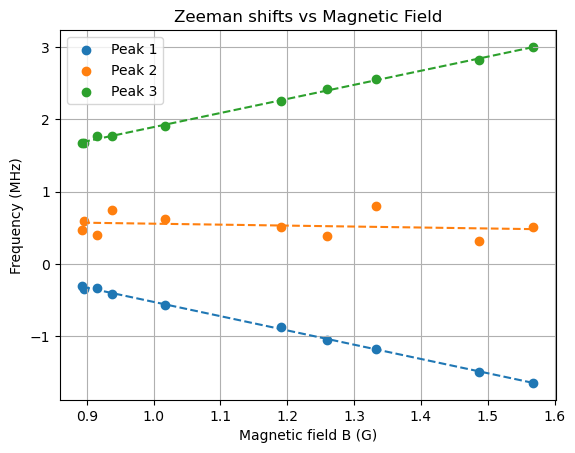


Fixed zero-field Zeeman fit
Zero field position Y0 = -0.29100 V
c = 2.14090 ± 0.12828 MHz/V
d = 1.65853 ± 0.09827 MHz

Expected Zeeman coefficient:
2*gJ*muB/h = 4.20212 MHz/G

Magnetic field calibration
B(Y) = 0.50948 * (Y + 0.291) G
Y = -0.500 V   B = -0.10648 G
Y = -0.350 V   B = -0.03006 G
Y = -0.200 V   B =  0.04636 G
Y =  0.000 V   B =  0.14826 G
Y =  0.200 V   B =  0.25015 G
Y =  0.500 V   B =  0.40300 G
Y =  0.600 V   B =  0.45395 G
Y =  0.700 V   B =  0.50490 G
Y =  0.900 V   B =  0.60679 G
Y =  1.000 V   B =  0.65774 G

Linear calibration
B ≈ 0.50948 * Y + 0.14826 G

Zero field check:
B(-0.291) = -0.00000 G


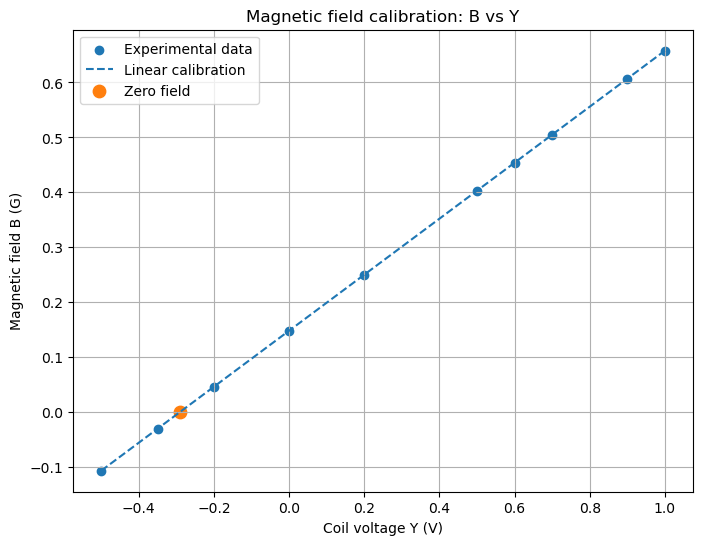

In [114]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# ==========================
# Dataset 1 (positive Y)
# ==========================
y1 = np.array([0.0, 0.2, 0.5, 0.6, 0.7, 0.9, 1.0])

p1_1 = np.array([
    -0.414,
    -0.5722,
    -0.891,
    -1.052,
    -1.172,
    -1.494,
    -1.643
])

p2_1 = np.array([
    0.750,
    0.6182,
    0.511,
    0.390,
    0.800,
    0.320,
    0.513
])

p3_1 = np.array([
    1.775,
    1.9032,
    2.276,
    2.420,
    2.556,
    2.197,
    3.004
])


# ==========================
# Dataset 2 (negative Y)
# ==========================
y2 = -np.array([0.2, 0.35, 0.5])

p1_2 = np.array([
    -0.341,
    -0.303,
    -0.331
])

p2_2 = np.array([
    0.598,
    0.473,
    0.408
])

p3_2 = np.array([
    1.681,
    1.674,
    1.767
])

# ==========================
# Zeeman parameters
# ==========================
gJ = 1.50116
muB_over_h = 1.3996246   # MHz/G
zeeman_slope = gJ * muB_over_h

print("Expected Zeeman slope:")
print(f"dν/dB = {zeeman_slope:.5f} MHz/G")


# ==========================
# Zeeman splitting Δν
# ==========================
splitting = p3_all - p1_all


# ==========================
# MODELLO NON LINEARE Δν(Z)
# ==========================
def zeeman_model(z, a, b, c, d):
    return c * np.sqrt(np.maximum(a + (b + z)**2, 0)) + d


# Initial guess (IMPORTANTISSIMO)
p0 = [0.0, 0.0, 2 * zeeman_slope, 0.0]

params, cov = curve_fit(zeeman_model, y_all, splitting, p0=p0)
err = np.sqrt(np.diag(cov))

print("\n==========================")
print("Zeeman splitting fit")
print("==========================")
print(f"a = {params[0]:.5f} ± {err[0]:.5f}")
print(f"b = {params[1]:.5f} ± {err[1]:.5f}")
print(f"c = {params[2]:.5f} ± {err[2]:.5f}")
print(f"d = {params[3]:.5f} ± {err[3]:.5f}")


# ==========================
# RICOSTRUZIONE CAMPO B(Z)
# ==========================
def B_model(z, a, b):
    return np.sqrt(np.maximum(a + (b + z)**2, 0))

B_fit_data = B_model(y_all, params[0], params[1])


# ==========================
# FIT LINEARE ν(B)
# ==========================
def linear(B, slope, intercept):
    return slope * B + intercept

p1, cov1 = curve_fit(linear, B_fit_data, p1_all)
p2, cov2 = curve_fit(linear, B_fit_data, p2_all)
p3, cov3 = curve_fit(linear, B_fit_data, p3_all)

err1 = np.sqrt(np.diag(cov1))
err2 = np.sqrt(np.diag(cov2))
err3 = np.sqrt(np.diag(cov3))


print("\n==========================")
print("Fit results ν(B)")
print("==========================")

print(f"Peak 1: slope = {p1[0]:.5f} ± {err1[0]:.5f}")
print(f"Peak 2: slope = {p2[0]:.5f} ± {err2[0]:.5f}")
print(f"Peak 3: slope = {p3[0]:.5f} ± {err3[0]:.5f}")


# ==========================
# PLOT Δν(Z)
# ==========================
z_plot = np.linspace(min(y_all), max(y_all), 300)

plt.figure()
plt.scatter(y_all, splitting, label="Data")
plt.plot(z_plot, zeeman_model(z_plot, *params), '--', label="Fit")
plt.xlabel("Coil voltage Y (V)")
plt.ylabel("Zeeman splitting Δν (MHz)")
plt.title("Zeeman splitting vs Coil voltage")
plt.legend()
plt.grid()


# ==========================
# PLOT ν(B)
# ==========================
B_plot = np.linspace(min(B_fit_data), max(B_fit_data), 300)

plt.figure()
plt.scatter(B_fit_data, p1_all, label="Peak 1")
plt.scatter(B_fit_data, p2_all, label="Peak 2")
plt.scatter(B_fit_data, p3_all, label="Peak 3")

plt.plot(B_plot, linear(B_plot, *p1), '--')
plt.plot(B_plot, linear(B_plot, *p2), '--')
plt.plot(B_plot, linear(B_plot, *p3), '--')

plt.xlabel("Magnetic field B (G)")
plt.ylabel("Frequency (MHz)")
plt.title("Zeeman shifts vs Magnetic Field")
plt.legend()
plt.grid()

plt.show()

# ==========================
# Fixed zero-field position
# ==========================

Y0 = -0.291   # Volt


# ==========================
# Zeeman splitting model
# ==========================

def zeeman_model_fixed(z, c, d):
    return c * np.abs(z - Y0) + d


p0 = [2 * zeeman_slope, 0]

params, cov = curve_fit(
    zeeman_model_fixed,
    y_all,
    splitting,
    p0=p0
)

err = np.sqrt(np.diag(cov))

c_fit, d_fit = params


print("\n==========================")
print("Fixed zero-field Zeeman fit")
print("==========================")

print(f"Zero field position Y0 = {Y0:.5f} V")
print(f"c = {c_fit:.5f} ± {err[0]:.5f} MHz/V")
print(f"d = {d_fit:.5f} ± {err[1]:.5f} MHz")

print("\nExpected Zeeman coefficient:")
print(f"2*gJ*muB/h = {2*zeeman_slope:.5f} MHz/G")



# ==========================
# Conversion Y -> B (Gauss)
# ==========================

# MHz/V divided by MHz/G gives G/V
alpha = c_fit / (2 * zeeman_slope)


def Y_to_B(y):
    """
    Magnetic field with sign
    Zero field at Y = -0.291 V
    """
    return alpha * (y - Y0)


B_gauss = Y_to_B(y_all)



# ==========================
# Print calibration
# ==========================

print("\n==========================")
print("Magnetic field calibration")
print("==========================")

print(f"B(Y) = {alpha:.5f} * (Y + 0.291) G")


for y, B in sorted(zip(y_all, B_gauss)):
    print(f"Y = {y: .3f} V   B = {B: .5f} G")



# ==========================
# Linear approximation
# ==========================

coeffs = np.polyfit(y_all, B_gauss, 1)

m = coeffs[0]
q = coeffs[1]


print("\n==========================")
print("Linear calibration")
print("==========================")

print(f"B ≈ {m:.5f} * Y + {q:.5f} G")

print("\nZero field check:")
print(f"B(-0.291) = {m*(-0.291)+q:.5f} G")




# ==========================
# Plot Y -> B calibration
# ==========================

Y_plot = np.linspace(min(y_all), max(y_all), 300)
B_plot = Y_to_B(Y_plot)

plt.figure(figsize=(8,6))

plt.scatter(y_all, B_gauss, label="Experimental data")

plt.plot(Y_plot, B_plot, '--', label="Linear calibration")

# zero field point
plt.scatter(Y0, 0, s=80, label="Zero field")

plt.xlabel("Coil voltage Y (V)")
plt.ylabel("Magnetic field B (G)")
plt.title("Magnetic field calibration: B vs Y")
plt.grid()
plt.legend()

plt.show()

Peak 1 fit:
f1(X) = -1.03429 X + -0.45291 MHz

Peak 2 fit:
f2(X) = -0.04743 X + 0.51110 MHz

Peak 3 fit:
f3(X) = 0.82620 X + 1.51654 MHz

Peak 1–Peak 3 intersection:
X-coil setting = -1.05857
Peak frequency = 0.64195 MHz

Fitted values at X = 0:
Peak 1 = -0.45291 MHz
Peak 2 = 0.51110 MHz
Peak 3 = 1.51654 MHz


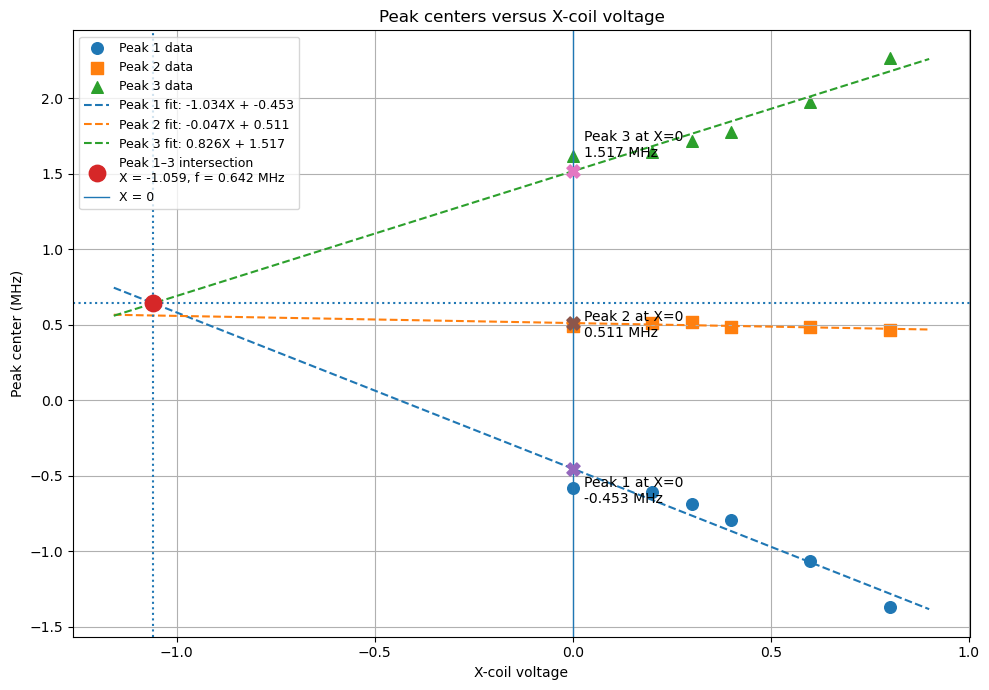

In [115]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# ==========================
# Experimental data
# ==========================

x_coils = np.array([
    0.0,
    0.2,
    0.3,
    0.4,
    0.6,
    0.8
])

peak1 = np.array([
    -0.579383,
    -0.608571,
    -0.686591,
    -0.791707,
    -1.062600,
    -1.367507
])

peak2 = np.array([
    0.493225,
    0.508962,
    0.520509,
    0.486830,
    0.483569,
    0.464403
])

peak3 = np.array([
    1.615198,
    1.646021,
    1.719800,
    1.779240,
    1.971933,
    2.267293
])


# ==========================
# Linear fit
# ==========================

def linear(x, slope, intercept):
    return slope * x + intercept


p1, cov1 = curve_fit(linear, x_coils, peak1)
p2, cov2 = curve_fit(linear, x_coils, peak2)
p3, cov3 = curve_fit(linear, x_coils, peak3)

m1, b1 = p1
m2, b2 = p2
m3, b3 = p3


# ==========================
# Peak 1–Peak 3 intersection
# ==========================

x_intersection = (b3 - b1) / (m1 - m3)
frequency_intersection = linear(x_intersection, m1, b1)


print("Peak 1 fit:")
print(f"f1(X) = {m1:.5f} X + {b1:.5f} MHz")

print("\nPeak 2 fit:")
print(f"f2(X) = {m2:.5f} X + {b2:.5f} MHz")

print("\nPeak 3 fit:")
print(f"f3(X) = {m3:.5f} X + {b3:.5f} MHz")

print("\nPeak 1–Peak 3 intersection:")
print(f"X-coil setting = {x_intersection:.5f}")
print(f"Peak frequency = {frequency_intersection:.5f} MHz")

print("\nFitted values at X = 0:")
print(f"Peak 1 = {b1:.5f} MHz")
print(f"Peak 2 = {b2:.5f} MHz")
print(f"Peak 3 = {b3:.5f} MHz")


# ==========================
# Plot
# ==========================

x_min = min(0, x_intersection) - 0.1
x_max = max(x_coils.max(), x_intersection) + 0.1
x_fit = np.linspace(x_min, x_max, 500)

plt.figure(figsize=(10, 7))

# Experimental data
plt.scatter(
    x_coils,
    peak1,
    marker="o",
    s=70,
    label="Peak 1 data"
)

plt.scatter(
    x_coils,
    peak2,
    marker="s",
    s=70,
    label="Peak 2 data"
)

plt.scatter(
    x_coils,
    peak3,
    marker="^",
    s=70,
    label="Peak 3 data"
)

# Linear fits
plt.plot(
    x_fit,
    linear(x_fit, *p1),
    "--",
    label=f"Peak 1 fit: {m1:.3f}X + {b1:.3f}"
)

plt.plot(
    x_fit,
    linear(x_fit, *p2),
    "--",
    label=f"Peak 2 fit: {m2:.3f}X + {b2:.3f}"
)

plt.plot(
    x_fit,
    linear(x_fit, *p3),
    "--",
    label=f"Peak 3 fit: {m3:.3f}X + {b3:.3f}"
)

# Peak 1–Peak 3 intersection
plt.scatter(
    x_intersection,
    frequency_intersection,
    s=140,
    zorder=10,
    label=(
        "Peak 1–3 intersection\n"
        f"X = {x_intersection:.3f}, "
        f"f = {frequency_intersection:.3f} MHz"
    )
)

plt.axvline(
    x_intersection,
    linestyle=":",
    linewidth=1.5
)

plt.axhline(
    frequency_intersection,
    linestyle=":",
    linewidth=1.5
)

# Fitted values at X = 0
plt.scatter(0, b1, s=90, marker="X", zorder=10)
plt.scatter(0, b2, s=90, marker="X", zorder=10)
plt.scatter(0, b3, s=90, marker="X", zorder=10)

plt.annotate(
    f"Peak 1 at X=0\n{b1:.3f} MHz",
    xy=(0, b1),
    xytext=(8, -25),
    textcoords="offset points"
)

plt.annotate(
    f"Peak 2 at X=0\n{b2:.3f} MHz",
    xy=(0, b2),
    xytext=(8, -10),
    textcoords="offset points"
)

plt.annotate(
    f"Peak 3 at X=0\n{b3:.3f} MHz",
    xy=(0, b3),
    xytext=(8, 10),
    textcoords="offset points"
)

plt.axvline(
    0,
    linewidth=1,
    linestyle="-",
    label="X = 0"
)

plt.xlabel("X-coil voltage")
plt.ylabel("Peak center (MHz)")
plt.title("Peak centers versus X-coil voltage")

plt.grid(True)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

Peak 1: b = 0.02327
Peak 3: b = 0.00550


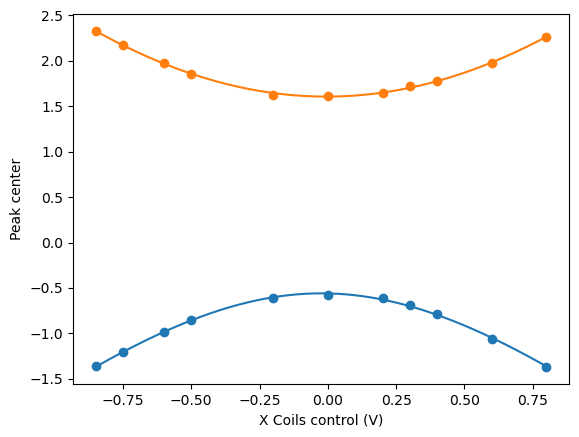

In [116]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

p1_all = np.array([
 -0.579383,
 -0.608571,
 -0.686591,
 -0.791707,
 -1.062600,
 -1.367507,
 -0.609854,
 -0.857266,
 -0.989966,
 -1.207772,
 -1.359008
])


p3_all = np.array([
 1.615198,
 1.646021,
 1.719800,
 1.779240,
 1.971933,
 2.267293,
 1.626795,
 1.858164,
 1.973395,
 2.176212,
 2.327551
])

x_all = np.array([
  0.0,
  0.2,
  0.3,
  0.4,
  0.6,
  0.8,
 -0.2,
 -0.5,
 -0.6,
 -0.75,
 -0.85
])

# Model
def model(z, a, b, c, d):
    return c * np.sqrt(np.maximum(a + (b + z)**2, 0))+d

# Better initial guesses
p0_1 = [1.0, 0.0, -1.0, 0]   # Peak 1 (negative)
p0_3 = [1.0, 0.0, 1.0, 0]    # Peak 3 (positive)

# Bounds: a ≥ 0
bounds = ([0, -np.inf, -np.inf, -np.inf], [np.inf, np.inf, np.inf, np.inf])

# Fit
params1, _ = curve_fit(model, x_all, p1_all, p0=p0_1, bounds=bounds)
params3, _ = curve_fit(model, x_all, p3_all, p0=p0_3, bounds=bounds)

a1, b1, c1, d1 = params1
a3, b3, c3, d3 = params3

# Print b values
print(f"Peak 1: b = {b1:.5f}")
print(f"Peak 3: b = {b3:.5f}")

# Smooth curve
x_fit = np.linspace(x_all.min(), x_all.max(), 500)

# Plot
plt.figure()

plt.scatter(x_all, p1_all)
plt.scatter(x_all, p3_all)

plt.plot(x_fit, model(x_fit, *params1))
plt.plot(x_fit, model(x_fit, *params3))

plt.xlabel("X Coils control (V)")
plt.ylabel("Peak center")

plt.show()



Generalized Asymmetric Peak Fit
Peak height = 909.092047 ± 1.216309
Peak position = 0.597908 ± 0.001199
Sigma left = 0.394227 ± 0.002869
Sigma right = 0.091123 ± 0.003870
Beta right = 1.155368 ± 0.035478
Offset = 497.517315 ± 0.413690
FWHM = 0.585061
Reduced chi-squared = 19.0596


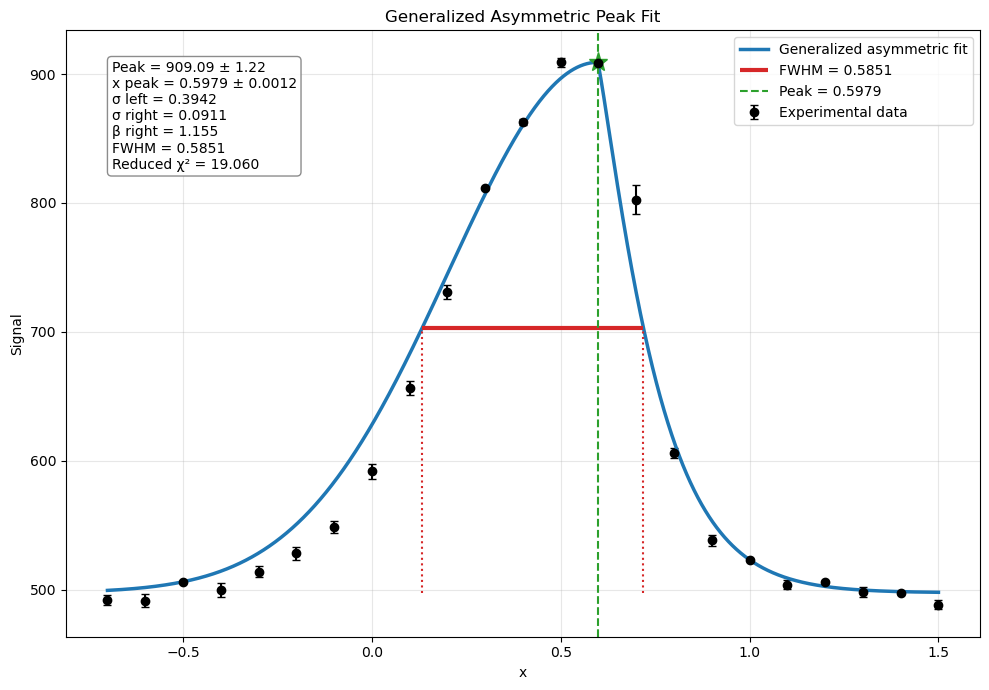

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# ==========================
# Load CSV
# ==========================

filename = (
    r"F:\Experiments\Sr\Selection_experiment\2026\08\28"
    r"\2026-08-28_0146_center_y.csv"
)

data = np.loadtxt(filename, delimiter=",")

x = data[:, 0]
y = data[:, 1]
y_err = data[:, 2]


# Remove invalid points
valid = (
    np.isfinite(x)
    & np.isfinite(y)
    & np.isfinite(y_err)
    & (y_err > 0)
)

x = x[valid]
y = y[valid]
y_err = y_err[valid]


# Sort by x
order = np.argsort(x)

x = x[order]
y = y[order]
y_err = y_err[order]


# ==========================
# Generalized asymmetric peak
# ==========================

def asymmetric_peak(
    x,
    peak_height,
    x_peak,
    sigma_left,
    sigma_right,
    beta_right,
    offset
):
    """
    Left side: ordinary Gaussian.

    Right side: generalized Gaussian with fitted exponent beta_right.

    beta_right = 2: Gaussian
    beta_right < 2: longer/heavier right tail
    beta_right > 2: flatter top and sharper right edge
    """

    result = np.empty_like(x, dtype=float)

    left = x < x_peak
    right = ~left

    amplitude = peak_height - offset

    result[left] = offset + amplitude * np.exp(
        -0.5 * np.abs(
            (x[left] - x_peak) / sigma_left
        )**2
    )

    result[right] = offset + amplitude * np.exp(
        -0.5 * np.abs(
            (x[right] - x_peak) / sigma_right
        )**beta_right
    )

    return result


# ==========================
# Initial guesses
# ==========================

y_min = np.min(y)
y_max = np.max(y)
y_range = y_max - y_min

scan_range = np.max(x) - np.min(x)

x_peak_guess = x[np.argmax(y)]

# Estimate offset from the scan edges
n_edge = max(1, len(y) // 10)

edge_values = np.concatenate([
    y[:n_edge],
    y[-n_edge:]
])

offset_guess = np.median(edge_values)

sigma_guess = scan_range / 10

# Place the initial guess slightly inside the upper bound
peak_height_guess = y_max - 1e-6 * max(y_range, 1)


p0 = [
    peak_height_guess,  # peak_height
    x_peak_guess,       # x_peak
    sigma_guess,        # sigma_left
    sigma_guess,        # sigma_right
    2.0,                # beta_right
    offset_guess        # offset
]


# ==========================
# Parameter bounds
# ==========================

minimum_sigma = max(scan_range / 10000, 1e-9)

bounds_lower = [
    y_min,             # peak_height
    np.min(x),         # x_peak
    minimum_sigma,     # sigma_left
    minimum_sigma,     # sigma_right
    0.5,               # beta_right
    y_min - y_range    # offset
]

bounds_upper = [
    y_max,             # peak cannot exceed measured maximum
    np.max(x),         # x_peak
    scan_range,        # sigma_left
    scan_range,        # sigma_right
    6.0,               # beta_right
    y_max              # offset
]


# ==========================
# Fit
# ==========================

params, covariance = curve_fit(
    asymmetric_peak,
    x,
    y,
    p0=p0,
    sigma=y_err,
    absolute_sigma=True,
    bounds=(bounds_lower, bounds_upper),
    maxfev=100000
)

errors = np.sqrt(np.diag(covariance))


(
    peak_height,
    x_peak,
    sigma_left,
    sigma_right,
    beta_right,
    offset
) = params


(
    peak_height_err,
    x_peak_err,
    sigma_left_err,
    sigma_right_err,
    beta_right_err,
    offset_err
) = errors


# ==========================
# Calculate FWHM
# ==========================

left_half_width = sigma_left * np.sqrt(2 * np.log(2))

right_half_width = sigma_right * (
    2 * np.log(2)
)**(1 / beta_right)

x_left = x_peak - left_half_width
x_right = x_peak + right_half_width

FWHM = x_right - x_left

half_max = offset + 0.5 * (peak_height - offset)


# ==========================
# Goodness of fit
# ==========================

y_model = asymmetric_peak(x, *params)

normalized_residuals = (y - y_model) / y_err

chi_squared = np.sum(normalized_residuals**2)
degrees_of_freedom = len(y) - len(params)

if degrees_of_freedom > 0:
    reduced_chi_squared = chi_squared / degrees_of_freedom
else:
    reduced_chi_squared = np.nan


# ==========================
# Print results
# ==========================

print("\n================================")
print("Generalized Asymmetric Peak Fit")
print("================================")

print(
    f"Peak height = {peak_height:.6f} "
    f"± {peak_height_err:.6f}"
)

print(
    f"Peak position = {x_peak:.6f} "
    f"± {x_peak_err:.6f}"
)

print(
    f"Sigma left = {sigma_left:.6f} "
    f"± {sigma_left_err:.6f}"
)

print(
    f"Sigma right = {sigma_right:.6f} "
    f"± {sigma_right_err:.6f}"
)

print(
    f"Beta right = {beta_right:.6f} "
    f"± {beta_right_err:.6f}"
)

print(
    f"Offset = {offset:.6f} "
    f"± {offset_err:.6f}"
)

print(f"FWHM = {FWHM:.6f}")
print(f"Reduced chi-squared = {reduced_chi_squared:.4f}")


# ==========================
# Smooth fitted curve
# ==========================

x_fit = np.linspace(
    np.min(x),
    np.max(x),
    10000
)

y_fit = asymmetric_peak(x_fit, *params)


# ==========================
# Plot
# ==========================

fig, ax = plt.subplots(figsize=(10, 7))


ax.errorbar(
    x,
    y,
    yerr=y_err,
    fmt="o",
    color="black",
    markersize=6,
    capsize=3,
    label="Experimental data"
)


ax.plot(
    x_fit,
    y_fit,
    color="tab:blue",
    linewidth=2.5,
    label="Generalized asymmetric fit"
)


# FWHM
ax.hlines(
    half_max,
    x_left,
    x_right,
    color="tab:red",
    linewidth=3,
    label=f"FWHM = {FWHM:.4f}"
)

ax.vlines(
    [x_left, x_right],
    offset,
    half_max,
    colors="tab:red",
    linestyles=":"
)


# Peak
ax.axvline(
    x_peak,
    color="tab:green",
    linestyle="--",
    label=f"Peak = {x_peak:.4f}"
)

ax.plot(
    x_peak,
    peak_height,
    marker="*",
    color="tab:green",
    markersize=14
)


# ==========================
# Results box
# ==========================

textstr = (
    f"Peak = {peak_height:.2f} ± {peak_height_err:.2f}\n"
    f"x peak = {x_peak:.4f} ± {x_peak_err:.4f}\n"
    f"σ left = {sigma_left:.4f}\n"
    f"σ right = {sigma_right:.4f}\n"
    f"β right = {beta_right:.3f}\n"
    f"FWHM = {FWHM:.4f}\n"
    f"Reduced χ² = {reduced_chi_squared:.3f}"
)

ax.text(
    0.05,
    0.95,
    textstr,
    transform=ax.transAxes,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        edgecolor="gray",
        alpha=0.9
    )
)


ax.set_xlabel("x")
ax.set_ylabel("Signal")
ax.set_title("Generalized Asymmetric Peak Fit")

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()